# `HilbertKFold`

`HilbertKFold` assigns observations to folds so that **each fold is a spatially spread-out subsample of the whole study area** -- every fold covers the entire region, not a compact geographic block.

Points are sorted along the **Hilbert space-filling curve** (`GeoSeries.hilbert_distance`).  The Hilbert curve is continuous with no quadrant-boundary discontinuities, so spatially adjacent observations always receive consecutive codes.  Assigning every k-th point in the sorted order to the same fold guarantees maximum within-fold spatial spread -- analogous to a quasi-random spatial sample.

This maximises the **mean within-fold nearest-neighbour distance** and ensures each fold is geographically representative of the whole region.

In [1]:
import numpy
import geopandas
import colormaps
from scipy import stats
import matplotlib.pyplot as plt
import geodatasets
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from scipy.spatial.distance import cdist

from spml.validation import HilbertKFold

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_health")).to_crs("EPSG:32616")
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())
print(f"n = {len(chicago)} community areas")

n = 77 community areas


## Hilbert distance and fold assignment

`HilbertKFold` internally calls `GeoSeries.hilbert_distance()` to place every area on a 1-D curve that preserves spatial proximity, then assigns every k-th position in that sorted order to the same fold. The first panel below shows the raw Hilbert distances; the second and third show how a 3-fold dispersion split compares with a random split.

In [3]:
chicago["hilbert_dist"] = chicago.geometry.hilbert_distance()
chicago['hilbert_rank'] = stats.rankdata(chicago.hilbert_dist)

N_SPLITS = 3
dkf = HilbertKFold(n_splits=N_SPLITS, random_state=0)
rkf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=0)

coords = numpy.column_stack([chicago.geometry.centroid.x, chicago.geometry.centroid.y])

disp_labels = numpy.full(len(chicago), -1, dtype=int)
for fi, (_, test) in enumerate(dkf.split(chicago)):
    disp_labels[test] = fi

rand_labels = numpy.full(len(chicago), -1, dtype=int)
for fi, (_, test) in enumerate(rkf.split(coords)):
    rand_labels[test] = fi

chicago["disp_fold"] = disp_labels
chicago["rand_fold"] = rand_labels

print("HilbertKFold fold sizes:", [numpy.sum(disp_labels==i) for i in range(N_SPLITS)])
print("Random KFold fold sizes:   ", [numpy.sum(rand_labels==i) for i in range(N_SPLITS)])

HilbertKFold fold sizes: [np.int64(26), np.int64(26), np.int64(25)]
Random KFold fold sizes:    [np.int64(26), np.int64(26), np.int64(25)]


## Fold assignment along the Hilbert curve

For *k* folds, every *k*-th consecutive position in the Hilbert rank order receives the same fold label: rank 0 → fold 0, rank 1 → fold 1, …, rank *k*−1 → fold *k*−1, rank *k* → fold 0, rank *k*+1 → fold 1, and so on.

The thin black line traces the Hilbert curve path through the community-area centroids; the colour of each polygon shows which fold it belongs to. Because the Hilbert curve visits spatially adjacent areas in consecutive steps, each fold ends up spread across the entire study area rather than concentrated in one corner.

/var/folders/l2/x261scsn70z33pvfm0bycvnh0000gp/T/ipykernel_37667/222675468.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title=f"{N_DEMO} folds", fontsize=9, loc="lower right", markerscale=1.4)
/var/folders/l2/x261scsn70z33pvfm0bycvnh0000gp/T/ipykernel_37667/222675468.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f"{N_DEMO} folds", fontsize=9, loc="lower right", markerscale=1.4)


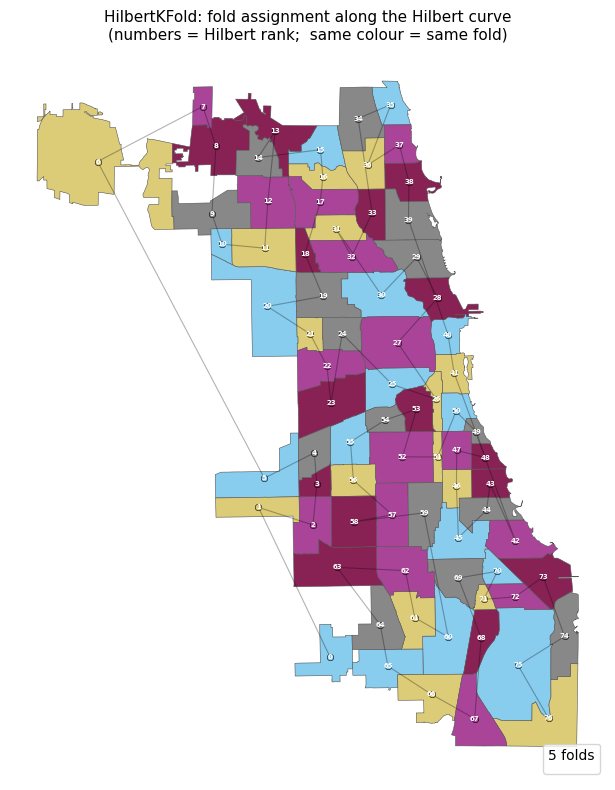

In [4]:
N_DEMO = 5

# Sort community areas by their Hilbert rank
sorted_idx = numpy.argsort(chicago["hilbert_rank"].values)

# Fold label = position-in-rank-order mod N_DEMO
stride_labels = numpy.empty(len(chicago), dtype=int)
for pos, area_i in enumerate(sorted_idx):
    stride_labels[area_i] = pos % N_DEMO
chicago["stride_fold"] = stride_labels

# Centroid coordinates in Hilbert rank order (for drawing the path)
centroids = chicago.geometry.centroid
cx = centroids.x.values[sorted_idx]
cy = centroids.y.values[sorted_idx]

demo_colors = [colormaps.safe(i / (N_DEMO - 1)) for i in range(N_DEMO)]

fig, ax = plt.subplots(figsize=(7, 8))

# Polygons coloured by fold
for fi in range(N_DEMO):
    chicago[chicago.stride_fold == fi].plot(
        ax=ax, color=demo_colors[fi], edgecolor="#555", linewidth=0.4,
        label=f"fold {fi}",
    )

# Hilbert curve path through centroids
ax.plot(cx, cy, color="k", linewidth=0.8, alpha=0.3, zorder=4)

# Centroid dots coloured by fold, labelled with Hilbert rank
for pos in range(len(sorted_idx)):
    fi = pos % N_DEMO
    ax.scatter(cx[pos], cy[pos], color=demo_colors[fi],
               s=22, edgecolors="k", linewidths=0.4, zorder=5)
    ax.annotate(
        str(pos), (cx[pos], cy[pos]),
        fontsize=5, ha="center", va="center",
        color="white", fontweight="bold", zorder=6,
    )

ax.legend(title=f"{N_DEMO} folds", fontsize=9, loc="lower right", markerscale=1.4)
ax.set_title(
    "HilbertKFold: fold assignment along the Hilbert curve\n"
    "(numbers = Hilbert rank;  same colour = same fold)",
    fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
def mean_nn(labels, coords, n_splits):
    dists = []
    for fi in range(n_splits):
        c = coords[labels == fi]
        if len(c) < 2: continue
        D = cdist(c, c); numpy.fill_diagonal(D, numpy.inf)
        dists.append(D.min(axis=1).mean())
    return numpy.mean(dists)


d_disp = mean_nn(disp_labels, coords, N_SPLITS)
d_rand = mean_nn(rand_labels, coords, N_SPLITS)
print(f"HilbertKFold mean within-fold NN: {d_disp/1000:.2f} km")
print(f"Random KFold    mean within-fold NN: {d_rand/1000:.2f} km")

HilbertKFold mean within-fold NN: 3.31 km
Random KFold    mean within-fold NN: 3.08 km


## Figure

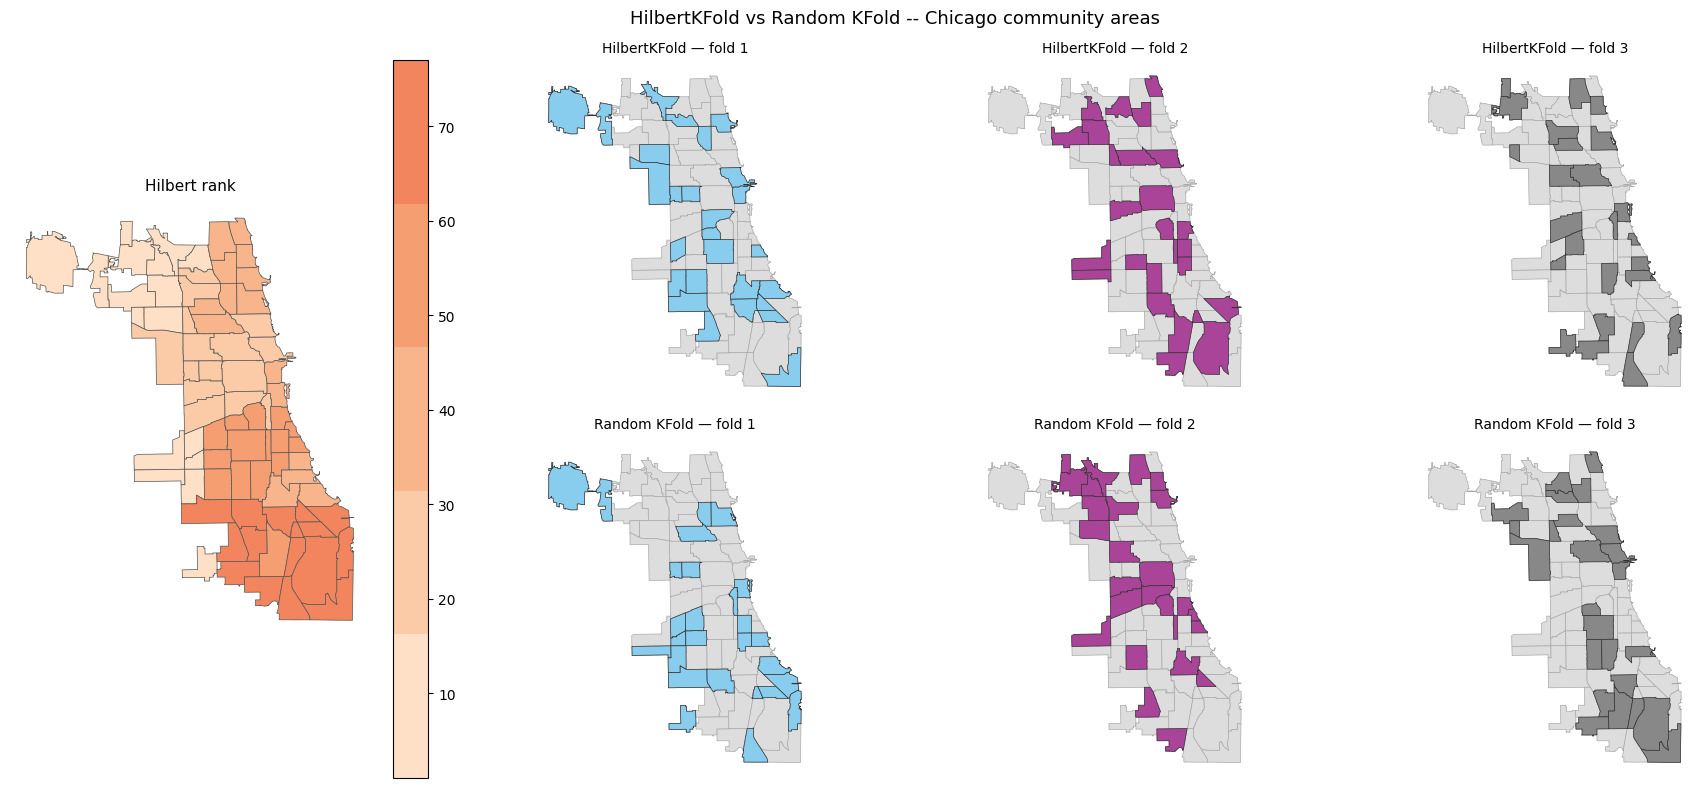

In [6]:
fold_colors = [colormaps.safe(i / (N_SPLITS - 1)) for i in range(N_SPLITS)]

fig, axes = plt.subplot_mosaic(
    [["hilbert", "d0", "d1", "d2"],
    ["hilbert", "r0", "r1", "r2"]],
    figsize=(18, 8),
    subplot_kw={"aspect": "equal"},
)

chicago.plot(
    column="hilbert_rank",
    cmap=colormaps.peach[:5],
    ax=axes["hilbert"],
    edgecolor="#555",
    linewidth=0.5,
    legend=True,
)
axes["hilbert"].set_title("Hilbert rank", fontsize=11)
axes["hilbert"].axis("off")

for i in range(N_SPLITS):
    for prefix, fold_col, row_title in [
        ("d", "disp_fold", "HilbertKFold"),
        ("r", "rand_fold", "Random KFold"),
    ]:
        ax = axes[f"{prefix}{i}"]
        chicago.plot(ax=ax, color="#ddd", edgecolor="#aaa", linewidth=0.5)
        chicago[chicago[fold_col] == i].plot(
            ax=ax, color=fold_colors[i], edgecolor="#333", linewidth=0.5
        )
        ax.set_title(f"{row_title} — fold {i + 1}", fontsize=10)
        ax.axis("off")

fig.suptitle("HilbertKFold vs Random KFold -- Chicago community areas", fontsize=13)
fig.tight_layout()
plt.show()

## Cross-validation example

`split(X)` follows the sklearn cross-validator protocol and works
directly with `cross_val_score`.

In [7]:
y      = chicago["VlntCrRt"].fillna(0).values
X_feat = chicago[["PerCInc14", "Pov14", "Unemp14"]].fillna(0).values

disp_rmse, rand_rmse = [], []
for train, test in dkf.split(chicago):
    lr = LinearRegression().fit(X_feat[train], y[train])
    disp_rmse.append(root_mean_squared_error(y[test], lr.predict(X_feat[test])))
for train, test in rkf.split(coords):
    lr = LinearRegression().fit(X_feat[train], y[train])
    rand_rmse.append(root_mean_squared_error(y[test], lr.predict(X_feat[test])))

print(f"HilbertKFold  RMSE per fold: {[f'{r:.2f}' for r in disp_rmse]}  mean={numpy.mean(disp_rmse):.2f}")
print(f"Random KFold     RMSE per fold: {[f'{r:.2f}' for r in rand_rmse]}  mean={numpy.mean(rand_rmse):.2f}")

HilbertKFold  RMSE per fold: ['0.02', '0.03', '0.02']  mean=0.02
Random KFold     RMSE per fold: ['0.03', '0.02', '0.02']  mean=0.02


## Large example -- King County house sales (21 k points)

With a large point dataset the spatial structure of the folds becomes
even clearer.  We use 5 folds and compare `HilbertKFold` against
random k-fold on three metrics:

1. **Fold map** -- each point coloured by fold assignment
2. **Within-fold nearest-neighbour distance** -- higher means each fold
   covers the whole county more uniformly
3. **Fold RMSE** -- predicting log(price) from structural features;
   lower fold-to-fold variance means more reliable CV estimates

In [8]:
import geodatasets
import numpy
import geopandas

gdf_full = geopandas.read_file(geodatasets.get_path("geoda.home_sales")).to_crs("EPSG:32610")
gdf_full["log_price"] = numpy.log(gdf_full["price"])
gdf_full["decile"] = (
    gdf_full["log_price"].rank(pct=True).multiply(10).clip(upper=9.99).astype(int)
)
idx = (
    gdf_full.groupby("decile")
    .apply(lambda g: g.sample(min(60, len(g)), random_state=42), include_groups=False)
    .index.get_level_values(1)
)
gdf = gdf_full.loc[idx].reset_index(drop=True)
print(f"n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} - ${gdf.price.max():,.0f}")

n = 600 sales  |  price $84,000 - $3,168,750


In [9]:
N_SPLITS5 = 5
y5      = numpy.log(gdf["price"].values)
X_feat5 = gdf[["sqft_liv", "bedrooms", "bathrooms", "grade"]].fillna(0).values
coords5 = numpy.column_stack([gdf.geometry.x, gdf.geometry.y])

dkf5 = HilbertKFold(n_splits=N_SPLITS5, random_state=0)
rkf5 = KFold(n_splits=N_SPLITS5, shuffle=True, random_state=0)

disp_labels5 = numpy.full(len(gdf), -1, dtype=int)
disp_splits5 = list(dkf5.split(gdf))
for fi, (_, test) in enumerate(disp_splits5):
    disp_labels5[test] = fi

rand_splits5 = list(rkf5.split(X_feat5, y5))
rand_labels5 = numpy.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(rand_splits5):
    rand_labels5[test] = fi

gdf["disp_fold5"] = disp_labels5


def fold_nn(splits, coords):
    means = []
    for _, test in splits:
        c = coords[test]
        D = cdist(c, c); numpy.fill_diagonal(D, numpy.inf)
        means.append(D.min(axis=1).mean())
    return means


spatial_nn5 = fold_nn(disp_splits5, coords5)
random_nn5  = fold_nn(rand_splits5,  coords5)

spatial_rmse5, random_rmse5 = [], []
for train, test in disp_splits5:
    lr = LinearRegression().fit(X_feat5[train], y5[train])
    spatial_rmse5.append(root_mean_squared_error(y5[test], lr.predict(X_feat5[test])))
for train, test in rand_splits5:
    lr = LinearRegression().fit(X_feat5[train], y5[train])
    random_rmse5.append(root_mean_squared_error(y5[test], lr.predict(X_feat5[test])))

print(f"HilbertKFold mean within-fold NN: {numpy.mean(spatial_nn5)/1000:.2f} km")
print(f"Random KFold    mean within-fold NN: {numpy.mean(random_nn5)/1000:.2f} km")

HilbertKFold mean within-fold NN: 2.27 km
Random KFold    mean within-fold NN: 1.86 km


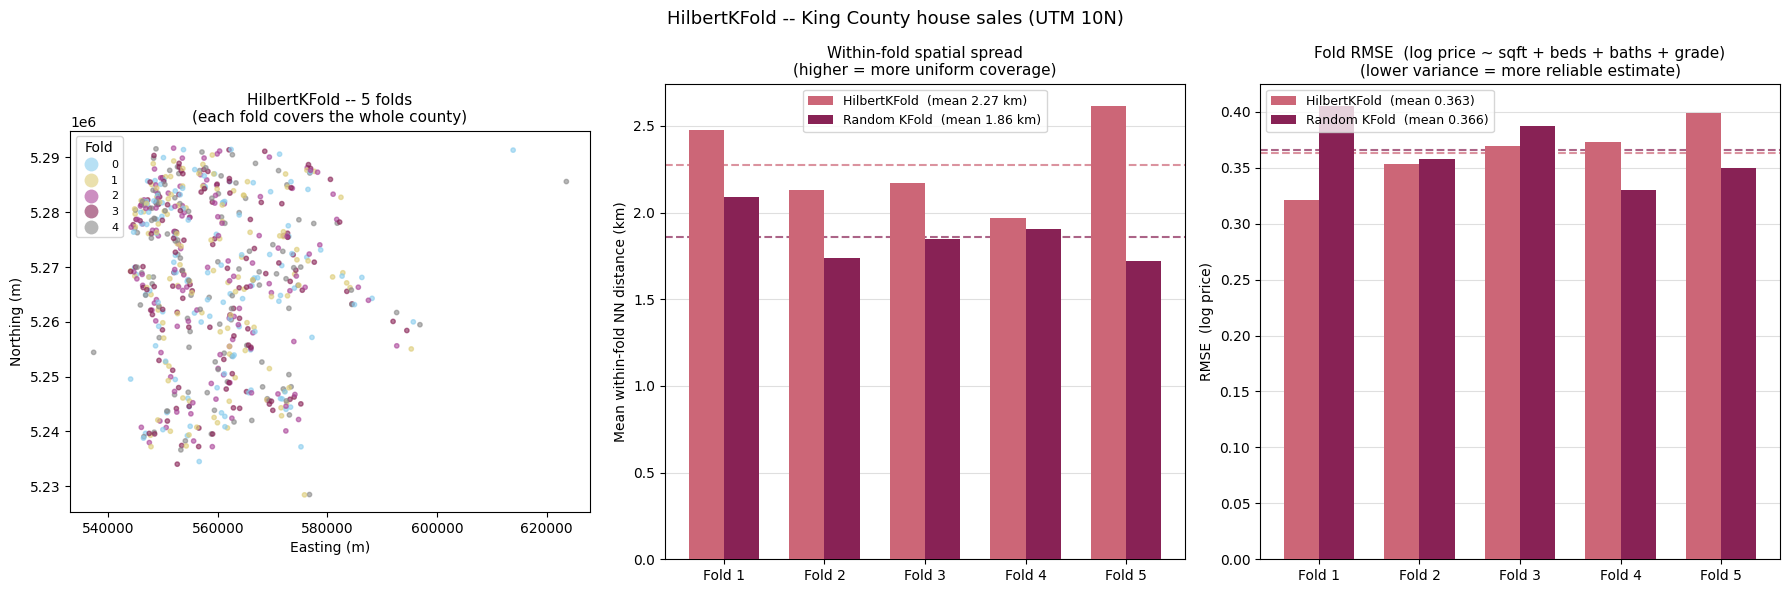

In [10]:
c_disp = colormaps.safe(0.15)
c_rand = colormaps.safe(0.75)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 -- fold map
gdf.plot(column="disp_fold5", cmap=colormaps.safe, categorical=True,
         markersize=10, alpha=0.6, legend=True,
         legend_kwds={"title": "Fold", "markerscale": 1, "fontsize": 8},
         ax=axes[0])
axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")
axes[0].set_title("HilbertKFold -- 5 folds\n(each fold covers the whole county)", fontsize=11)
axes[0].set_aspect("equal")

# Panel 2 -- within-fold NN distance
x_pos = numpy.arange(N_SPLITS5); w = 0.35
ax2 = axes[1]
ax2.bar(x_pos - w/2, [d/1000 for d in spatial_nn5], w, color=c_disp,
        label=f"HilbertKFold  (mean {numpy.mean(spatial_nn5)/1000:.2f} km)", zorder=3)
ax2.bar(x_pos + w/2, [d/1000 for d in random_nn5],  w, color=c_rand,
        label=f"Random KFold  (mean {numpy.mean(random_nn5)/1000:.2f} km)", zorder=3)
ax2.axhline(numpy.mean(spatial_nn5)/1000, color=c_disp, lw=1.5, ls="--", alpha=0.7)
ax2.axhline(numpy.mean(random_nn5)/1000,  color=c_rand, lw=1.5, ls="--", alpha=0.7)
ax2.set_xticks(x_pos); ax2.set_xticklabels([f"Fold {i+1}" for i in range(N_SPLITS5)])
ax2.set_ylabel("Mean within-fold NN distance (km)")
ax2.set_title("Within-fold spatial spread\n(higher = more uniform coverage)", fontsize=11)
ax2.legend(fontsize=9); ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)

# Panel 3 -- RMSE
ax3 = axes[2]
ax3.bar(x_pos - w/2, spatial_rmse5, w, color=c_disp,
        label=f"HilbertKFold  (mean {numpy.mean(spatial_rmse5):.3f})", zorder=3)
ax3.bar(x_pos + w/2, random_rmse5,  w, color=c_rand,
        label=f"Random KFold  (mean {numpy.mean(random_rmse5):.3f})", zorder=3)
ax3.axhline(numpy.mean(spatial_rmse5), color=c_disp, lw=1.5, ls="--", alpha=0.7)
ax3.axhline(numpy.mean(random_rmse5),  color=c_rand, lw=1.5, ls="--", alpha=0.7)
ax3.set_xticks(x_pos); ax3.set_xticklabels([f"Fold {i+1}" for i in range(N_SPLITS5)])
ax3.set_ylabel("RMSE  (log price)")
ax3.set_title("Fold RMSE  (log price ~ sqft + beds + baths + grade)\n"
              "(lower variance = more reliable estimate)", fontsize=11)
ax3.legend(fontsize=9); ax3.yaxis.grid(True, alpha=0.4); ax3.set_axisbelow(True)

fig.suptitle("HilbertKFold -- King County house sales (UTM 10N)", fontsize=13)
fig.tight_layout()
plt.show()